<a href="https://colab.research.google.com/github/Nav-del/Machine-Learning-Course/blob/main/PCA_codes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

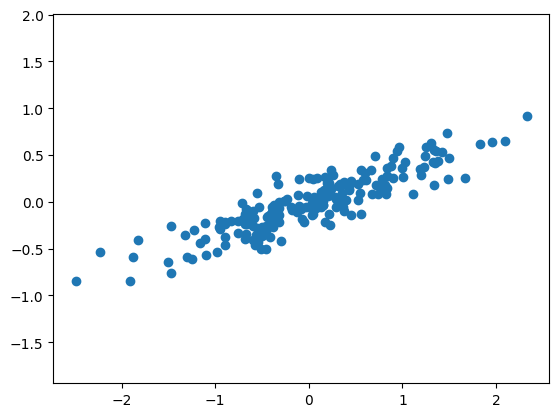

In [3]:
#initializes a random number generator object in NumPy using a specific seed value.
rng = np.random.RandomState(1)

X=np.dot(rng.rand(2,2),rng.randn(2,200)).T#generate between 2 to 200
#.T transform to row (column previously)
plt.scatter(X[:,0],X[:,1])
plt.axis('equal')
plt.show()

In [4]:
pca = PCA(n_components=2)
pca.fit(X)

PCA(n_components=2)

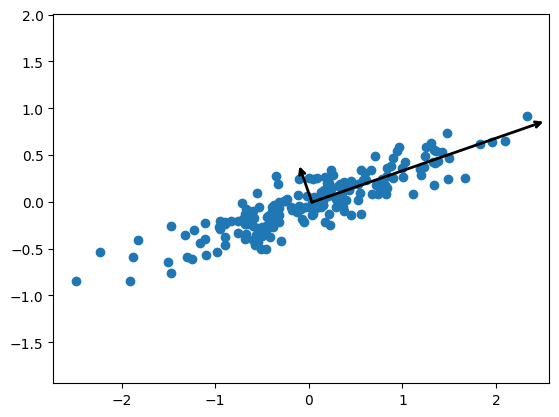

In [6]:
def draw_vector(v0, v1, ax=None): #function to draw vector
    ax = ax or plt.gca()
    #now style the vectors
    arrowprops = dict(arrowstyle='->',
                      linewidth=2,
                      shrinkA=0, shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.scatter(X[:, 0], X[:, 1])
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal')
plt.show()


The previous code helps us understand what PCA actually "sees" inside the data by visually plotting its hidden internal axes and showing their relative strength.Instead of showing the compression itself, it plots the principal components directly over your raw data as arrows.

1. The Direction of the Arrows (pca.components_)
  What it shows: The alignment of the arrows shows the directions of maximum variation in your dataset.
  
  The Math: pca.components_ gives the eigenvectors. These define the new coordinate system (the principal axes) that PCA creates to better describe your data.


2. The Length of the Arrows (3 * np.sqrt(length))
  What it shows: The length of each arrow indicates how spread out (variable) the data is along that specific axis. One arrow will be long (major axis), and the other will be much shorter (minor axis).
  
  The Math: pca.explained_variance_ gives the eigenvalues (variance \(\sigma ^{2}\)). Taking the square root (np.sqrt(length)) converts it to standard deviation (\(\sigma \)). Multiplying by 3 extends the arrow out to cover roughly \(99.7\%\) of the data distribution along that axis (based on the Empirical Rule in statistics).


3. The Starting Point (pca.mean_)
  What it shows: The arrows originate at pca.mean_, which is the exact center of gravity (centroid) of your data cloud.

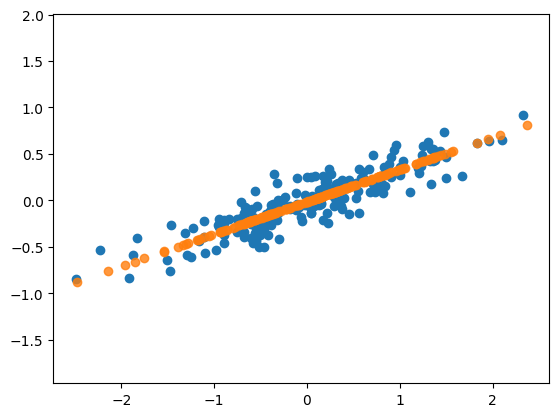

In [7]:
pca = PCA(n_components=1)
pca.fit(X)
X_pca = pca.transform(X)
X_new = pca.inverse_transform(X_pca)
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(X_new[:, 0], X_new[:, 1], alpha=0.8)
plt.axis('equal')
plt.show()


This code helps us visualize dimensionality reduction and lossy data compression using Principal Component Analysis (PCA).Specifically, it demonstrates what happens when you squeeze a 2D dataset down to 1D, and then try to rebuild it back into 2D space.

Key Takeaways from this Visualization

Visualizes Information Loss: The distance between an original point and its reconstructed point on the line represents the data lost during compression.Finds the Best Fit: It shows that PCA projects data points onto the line of maximum variance while minimizing the perpendicular distance from the data points to that line.